# IMDB Movie Review Sentiment — Neural Network Implementation & Hyperparameter Study

**Course:** TECH 405 — Artificial Neural Network and Deep Learning  
**Week 03 assignment** (continuation of the Week 2 EDA & feature-engineering notebook)

This notebook implements a neural network for **binary sentiment classification** (0 = negative, 1 = positive)
on the IMDB dataset chosen in Week 2 (`Train.csv` 40,000 · `Valid.csv` 5,000 · `Test.csv` 5,000).

**Workflow**

1. Load the data and rebuild the Week 2 preprocessing pipeline (cleaning → tokenising → padding).
2. Define an embedding-based feed-forward neural network and train a **baseline**.
3. Run a **one-factor-at-a-time hyperparameter study** (embedding size, width, depth, dropout, learning rate,
   batch size, optimiser, pooling, L2), scored on the **validation set only**.
4. Combine the findings into a **final configuration** and evaluate it once on the **test set** with a confusion
   matrix, precision, recall and F-score.

Preprocessing choices come straight from the Week 2 recommendations: vocabulary 20,000 words, `<OOV>` token,
sequence length 250, post-padding / post-truncation, stop-words **kept**, no class weighting.

In [1]:
import os, re, json, time, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
warnings.filterwarnings("ignore")

%pip install -q tensorflow
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import (confusion_matrix, classification_report, accuracy_score,
                             precision_score, recall_score, f1_score, roc_auc_score, roc_curve)

SEED = 42
def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed); tf.keras.utils.set_random_seed(seed)

set_seed()
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
os.makedirs("figures", exist_ok=True)
print("TensorFlow version:", tf.__version__)

Note: you may need to restart the kernel to use updated packages.
TensorFlow version: 2.21.0


## 1. Load the data

The notebook looks for the three CSV files in a few common locations, so it runs unchanged on another machine —
put the CSVs next to the notebook or edit `CANDIDATES`.

In [2]:
CANDIDATES = [".", "data", "moviesentiment",
              r"C:\Users\ybaav\OneDrive\Desktop\Week 2 AD\moviesentiment"]
FILES = ["Train.csv", "Valid.csv", "Test.csv"]
DATA_DIR = next((d for d in CANDIDATES
                 if all(os.path.exists(os.path.join(d, f)) for f in FILES)), None)
if DATA_DIR is None:
    raise FileNotFoundError("Put Train.csv, Valid.csv and Test.csv next to this notebook.")

train = pd.read_csv(os.path.join(DATA_DIR, "Train.csv"))
valid = pd.read_csv(os.path.join(DATA_DIR, "Valid.csv"))
test  = pd.read_csv(os.path.join(DATA_DIR, "Test.csv"))
for df in (train, valid, test):
    df["label"] = df["label"].astype(int)

print(f"Train: {train.shape}   Valid: {valid.shape}   Test: {test.shape}")
for name, df in [("Train", train), ("Valid", valid), ("Test", test)]:
    pos = df["label"].mean() * 100
    print(f"{name:<6} positive = {pos:.1f}%   negative = {100 - pos:.1f}%")

Train: (40000, 2)   Valid: (5000, 2)   Test: (5000, 2)
Train  positive = 50.0%   negative = 50.0%
Valid  positive = 50.3%   negative = 49.7%
Test   positive = 50.1%   negative = 49.9%


## 2. Preprocessing (Week 2 pipeline)

The `clean_text` function is identical to the one used in the Week 2 notebook. The tokenizer is **fitted on the
training reviews only**, so no information from the validation or test sets leaks into the vocabulary.

In [3]:
VOCAB_SIZE = 20000     # Week 2: covers ~94% of token occurrences
MAX_LEN    = 250       # Week 2: keeps most of each review, limits padding
OOV_TOKEN  = "<OOV>"

def clean_text(text):
    text = re.sub(r'<br\s*/?>', ' ', text)
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    text = re.sub(r"[^a-zA-Z']", ' ', text)
    text = text.lower()
    return re.sub(r'\s+', ' ', text).strip()

for df in (train, valid, test):
    df["clean_text"] = df["text"].apply(clean_text)

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(train["clean_text"])

def to_padded(texts):
    seqs = tokenizer.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen=MAX_LEN, padding="post", truncating="post")

X_train, y_train = to_padded(train["clean_text"]), train["label"].values
X_valid, y_valid = to_padded(valid["clean_text"]), valid["label"].values
X_test,  y_test  = to_padded(test["clean_text"]),  test["label"].values

print("X_train:", X_train.shape, " X_valid:", X_valid.shape, " X_test:", X_test.shape)
print("Unique words seen in train:", len(tokenizer.word_index))
print("\nReview 0 (cleaned):", train["clean_text"].iloc[0][:110], "...")
print("Review 0 (first 15 token ids):", X_train[0][:15])

X_train: (40000, 250)  X_valid: (5000, 250)  X_test: (5000, 250)
Unique words seen in train: 107969

Review 0 (cleaned): i grew up b watching and loving the thunderbirds all my mates at school watched we played thunderbirds before  ...
Review 0 (first 15 token ids): [  10 2159   53  485  147    3 1653    2 9715   29   57 5360   30  365
  287]


## 3. Model definition

The network is an **embedding-based feed-forward (dense) neural network**:

```
token ids (250) → Embedding → pooling → [Dense(ReLU) → Dropout] × depth → Dense(1, sigmoid)
```

The embedding layer turns each word id into a trainable vector; a pooling layer collapses the 250 word vectors
into one review vector; the dense layers then learn the decision boundary. Every hyperparameter lives in a
config dictionary so that experiments change exactly one thing at a time.

In [4]:
BASE = dict(emb_dim=32, hidden=[64], dropout=0.3, lr=1e-3,
            optimizer="adam", batch=64, pool="avg", l2=0.0)

def build_model(cfg):
    reg = regularizers.l2(cfg["l2"]) if cfg["l2"] > 0 else None
    inp = layers.Input(shape=(MAX_LEN,))
    x = layers.Embedding(VOCAB_SIZE, cfg["emb_dim"], mask_zero=(cfg["pool"] == "avg"))(inp)
    if   cfg["pool"] == "avg":  x = layers.GlobalAveragePooling1D()(x)
    elif cfg["pool"] == "max":  x = layers.GlobalMaxPooling1D()(x)
    else:                       x = layers.Flatten()(x)
    for units in cfg["hidden"]:
        x = layers.Dense(units, activation="relu", kernel_regularizer=reg)(x)
        x = layers.Dropout(cfg["dropout"])(x)
    out = layers.Dense(1, activation="sigmoid")(x)
    return keras.Model(inp, out)

def make_optimizer(name, lr):
    if name == "adam":    return keras.optimizers.Adam(lr)
    if name == "rmsprop": return keras.optimizers.RMSprop(lr)
    if name == "sgd":     return keras.optimizers.SGD(lr, momentum=0.9)
    raise ValueError(name)

build_model(BASE).summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 250)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 250, 32)   │    640,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 250)       │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ embedding[0][0],  │
│ (GlobalAveragePool… │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      2,112 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         65 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 642,177 (2.45 MB)

 Trainable params: 642,177 (2.45 MB)

 Non-trainable params: 0 (0.00 B)

## 4. Training and evaluation helpers

* **Loss:** binary cross-entropy (sigmoid output).
* **Early stopping:** stop when validation loss has not improved for 2 epochs and restore the best weights, so
  every run gets the same fair stopping rule and cannot over-train.
* **Metrics:** accuracy, precision, recall and F1 for the positive class, plus ROC-AUC.

In [5]:
MAX_EPOCHS = 20

def compute_metrics(y_true, prob, threshold=0.5):
    pred = (prob >= threshold).astype(int)
    return dict(accuracy=accuracy_score(y_true, pred),
                precision=precision_score(y_true, pred, zero_division=0),
                recall=recall_score(y_true, pred, zero_division=0),
                f1=f1_score(y_true, pred, zero_division=0),
                auc=roc_auc_score(y_true, prob))

def fmt(v):
    if isinstance(v, list):
        return "-".join(map(str, v)) if v else "none"
    return str(v)

def train_model(cfg, seed=SEED, verbose=0):
    keras.backend.clear_session()
    set_seed(seed)
    model = build_model(cfg)
    model.compile(optimizer=make_optimizer(cfg["optimizer"], cfg["lr"]),
                  loss="binary_crossentropy", metrics=["accuracy"])
    early = keras.callbacks.EarlyStopping(monitor="val_loss", patience=2,
                                          restore_best_weights=True)
    t0 = time.time()
    hist = model.fit(X_train, y_train, validation_data=(X_valid, y_valid),
                     epochs=MAX_EPOCHS, batch_size=cfg["batch"],
                     callbacks=[early], verbose=verbose)
    return model, hist.history, time.time() - t0

def run_experiment(label, cfg, group, seed=SEED):
    model, hist, secs = train_model(cfg, seed)
    prob = model.predict(X_valid, batch_size=512, verbose=0).ravel()
    m = compute_metrics(y_valid, prob)
    best = int(np.argmin(hist["val_loss"]))
    row = dict(group=group, label=label, cfg=cfg, params=model.count_params(),
               epochs=len(hist["loss"]), best_epoch=best + 1,
               train_acc=hist["accuracy"][best], val_acc=m["accuracy"],
               val_loss=hist["val_loss"][best], precision=m["precision"],
               recall=m["recall"], f1=m["f1"], auc=m["auc"], seconds=secs)
    return row, hist

## 5. Baseline model

A deliberately plain starting point (embedding size 32, one hidden layer of 64 ReLU units, dropout 0.3,
Adam with learning rate 0.001, batch size 64, average pooling). Every later experiment is compared against it.

In [6]:
baseline_model, baseline_hist, secs = train_model(BASE, verbose=2)
print(f"\nTraining time: {secs:.0f}s")


Epoch 1/20
625/625 - 9s - 14ms/step - accuracy: 0.8235 - loss: 0.4160 - val_accuracy: 0.8714 - val_loss: 0.2982
Epoch 2/20
625/625 - 8s - 12ms/step - accuracy: 0.9096 - loss: 0.2338 - val_accuracy: 0.8814 - val_loss: 0.2884
Epoch 3/20
625/625 - 8s - 13ms/step - accuracy: 0.9317 - loss: 0.1848 - val_accuracy: 0.8852 - val_loss: 0.2972
Epoch 4/20
625/625 - 8s - 13ms/step - accuracy: 0.9494 - loss: 0.1488 - val_accuracy: 0.8858 - val_loss: 0.3178

Training time: 33s


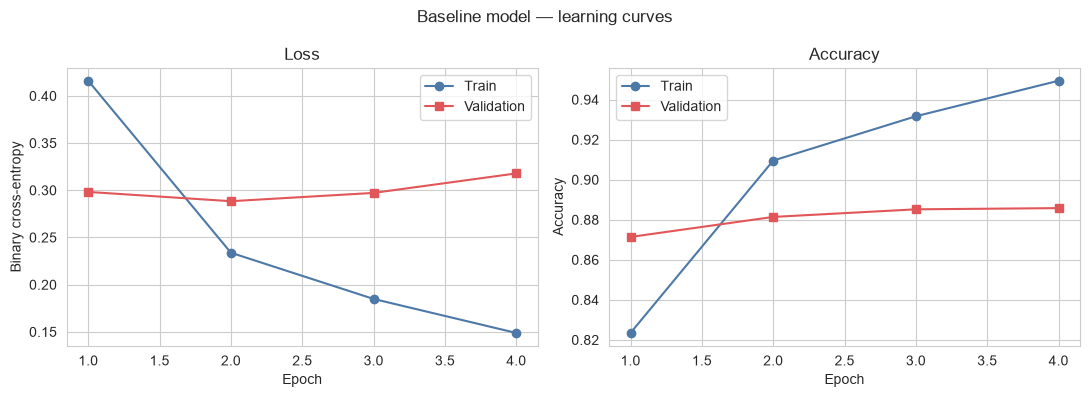

Baseline validation metrics: {'accuracy': 0.8814, 'precision': 0.8497, 'recall': 0.9284, 'f1': 0.8873, 'auc': 0.9549}


In [7]:
def plot_curves(hist, title, path):
    ep = range(1, len(hist["loss"]) + 1)
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    ax[0].plot(ep, hist["loss"], "o-", label="Train", color="#4e79a7")
    ax[0].plot(ep, hist["val_loss"], "s-", label="Validation", color="#e15759")
    ax[0].set(title="Loss", xlabel="Epoch", ylabel="Binary cross-entropy"); ax[0].legend()
    ax[1].plot(ep, hist["accuracy"], "o-", label="Train", color="#4e79a7")
    ax[1].plot(ep, hist["val_accuracy"], "s-", label="Validation", color="#e15759")
    ax[1].set(title="Accuracy", xlabel="Epoch", ylabel="Accuracy"); ax[1].legend()
    fig.suptitle(title); fig.tight_layout(); fig.savefig(path); plt.show()

plot_curves(baseline_hist, "Baseline model — learning curves", "figures/01_baseline_curves.png")

base_row = dict(group="Baseline", label="baseline", cfg=BASE)
prob = baseline_model.predict(X_valid, batch_size=512, verbose=0).ravel()
print("Baseline validation metrics:",
      {k: round(v, 4) for k, v in compute_metrics(y_valid, prob).items()})

## 6. Hyperparameter study

Nine hyperparameters are varied **one at a time** around the baseline (26 training runs in total, including the
baseline). All runs use the same seed, the same early-stopping rule and are scored on the **validation set** —
the test set is not touched until Section 8.

| Group | Values tried |
|---|---|
| Embedding dimension | 16, **32**, 64, 128 |
| Hidden units (1 layer) | 16, **64**, 128, 256 |
| Network depth (hidden layers of 64) | 0, **1**, 2, 3 |
| Dropout rate | 0.0, 0.2, **0.3**, 0.5 |
| Learning rate | 1e-4, 5e-4, **1e-3**, 5e-3, 1e-2 |
| Batch size | 32, **64**, 128, 256 |
| Optimiser | **Adam**, RMSprop, SGD + momentum |
| Pooling | **average**, max, flatten |
| L2 weight decay | **0**, 1e-4, 1e-3 |

Bold = baseline value. Single-seed differences smaller than roughly 0.3–0.5 accuracy points should be read as
noise, not as real effects; Section 8 re-checks the final choice with several seeds.

In [ ]:
GRID = {
    "Embedding dimension": ("emb_dim",   [16, 64, 128]),
    "Hidden units":        ("hidden",    [[16], [128], [256]]),
    "Network depth":       ("hidden",    [[], [64, 64], [64, 64, 64]]),
    "Dropout rate":        ("dropout",   [0.0, 0.2, 0.5]),
    "Learning rate":       ("lr",        [1e-4, 5e-4, 5e-3, 1e-2]),
    "Batch size":          ("batch",     [32, 128, 256]),
    "Optimiser":           ("optimizer", ["rmsprop", "sgd"]),
    "Pooling":             ("pool",      ["max", "flatten"]),
    "L2 regularisation":   ("l2",        [1e-4, 1e-3]),
}

# re-run the baseline through the same helper so its metrics are stored with the others
results = []
row0, _ = run_experiment("baseline", BASE, "Baseline")
results.append(row0)
histories = {"baseline": baseline_hist}

jobs = [(g, k, v) for g, (k, vals) in GRID.items() for v in vals]
for i, (group, key, value) in enumerate(jobs, 1):
    label = f"{key}={fmt(value)}"
    row, hist = run_experiment(label, {**BASE, key: value}, group)
    results.append(row); histories[label] = hist
    print(f"[{i:02d}/{len(jobs)}] {group:<20} {label:<18} "
          f"val_acc={row['val_acc']:.4f}  val_loss={row['val_loss']:.4f}  "
          f"epochs={row['epochs']:>2}  ({row['seconds']:.0f}s)")

[01/25] Embedding dimension  emb_dim=16         val_acc=0.8798  val_loss=0.2882  epochs= 4  (17s)
[02/25] Embedding dimension  emb_dim=64         val_acc=0.8776  val_loss=0.2856  epochs= 3  (42s)
[03/25] Embedding dimension  emb_dim=128        val_acc=0.8832  val_loss=0.2793  epochs= 3  (74s)
[04/25] Hidden units         hidden=16          val_acc=0.8872  val_loss=0.2869  epochs= 5  (41s)
[05/25] Hidden units         hidden=128         val_acc=0.8860  val_loss=0.2850  epochs= 4  (29s)
[06/25] Hidden units         hidden=256         val_acc=0.8804  val_loss=0.2836  epochs= 3  (25s)
[07/25] Network depth        hidden=none        val_acc=0.8842  val_loss=0.2746  epochs= 8  (72s)
[08/25] Network depth        hidden=64-64       val_acc=0.8798  val_loss=0.2867  epochs= 3  (43s)
[09/25] Network depth        hidden=64-64-64    val_acc=0.8800  val_loss=0.2827  epochs= 3  (33s)
[10/25] Dropout rate         dropout=0.0        val_acc=0.8864  val_loss=0.2843  epochs= 4  (64s)
[11/25] Dropout rate

### 6.1 Results table

All runs, sorted by validation accuracy (ties broken by validation loss).

In [ ]:
results_df = pd.DataFrame(results)
results_df.drop(columns="cfg").to_csv("hyperparameter_results.csv", index=False)

show = results_df.sort_values(["val_acc", "val_loss"], ascending=[False, True]).reset_index(drop=True)
show["run"] = show["label"]
cols = ["run", "params", "best_epoch", "train_acc", "val_acc", "val_loss", "precision", "recall", "f1"]
pd.set_option("display.width", 140)
print(show[cols].round(4).to_string(index=False))

              run  params  best_epoch  train_acc  val_acc  val_loss  precision  recall     f1
        hidden=16  640545           3     0.9231   0.8872    0.2869     0.8627  0.9224 0.8916
        lr=0.0001  642177          15     0.9315   0.8868    0.2748     0.8726  0.9073 0.8896
      dropout=0.0  642177           2     0.9125   0.8864    0.2843     0.8593  0.9256 0.8912
       hidden=128  644353           2     0.9146   0.8860    0.2850     0.8630  0.9193 0.8902
         lr=0.005  642177           1     0.8535   0.8846    0.2780     0.8704  0.9053 0.8875
      hidden=none  640033           6     0.9253   0.8842    0.2746     0.8641  0.9133 0.8880
         l2=0.001  642177           4     0.9333   0.8838    0.3088     0.8562  0.9240 0.8888
          lr=0.01  642177           1     0.8571   0.8834    0.2790     0.8797  0.8898 0.8847
      emb_dim=128 2568321           1     0.8421   0.8832    0.2793     0.8633  0.9121 0.8870
      dropout=0.2  642177           2     0.9111   0.8830   

### 6.2 Effect of each hyperparameter

Bars = validation accuracy, diamonds = training accuracy at the best epoch (the gap between them is overfitting). The starred bar is the baseline value.

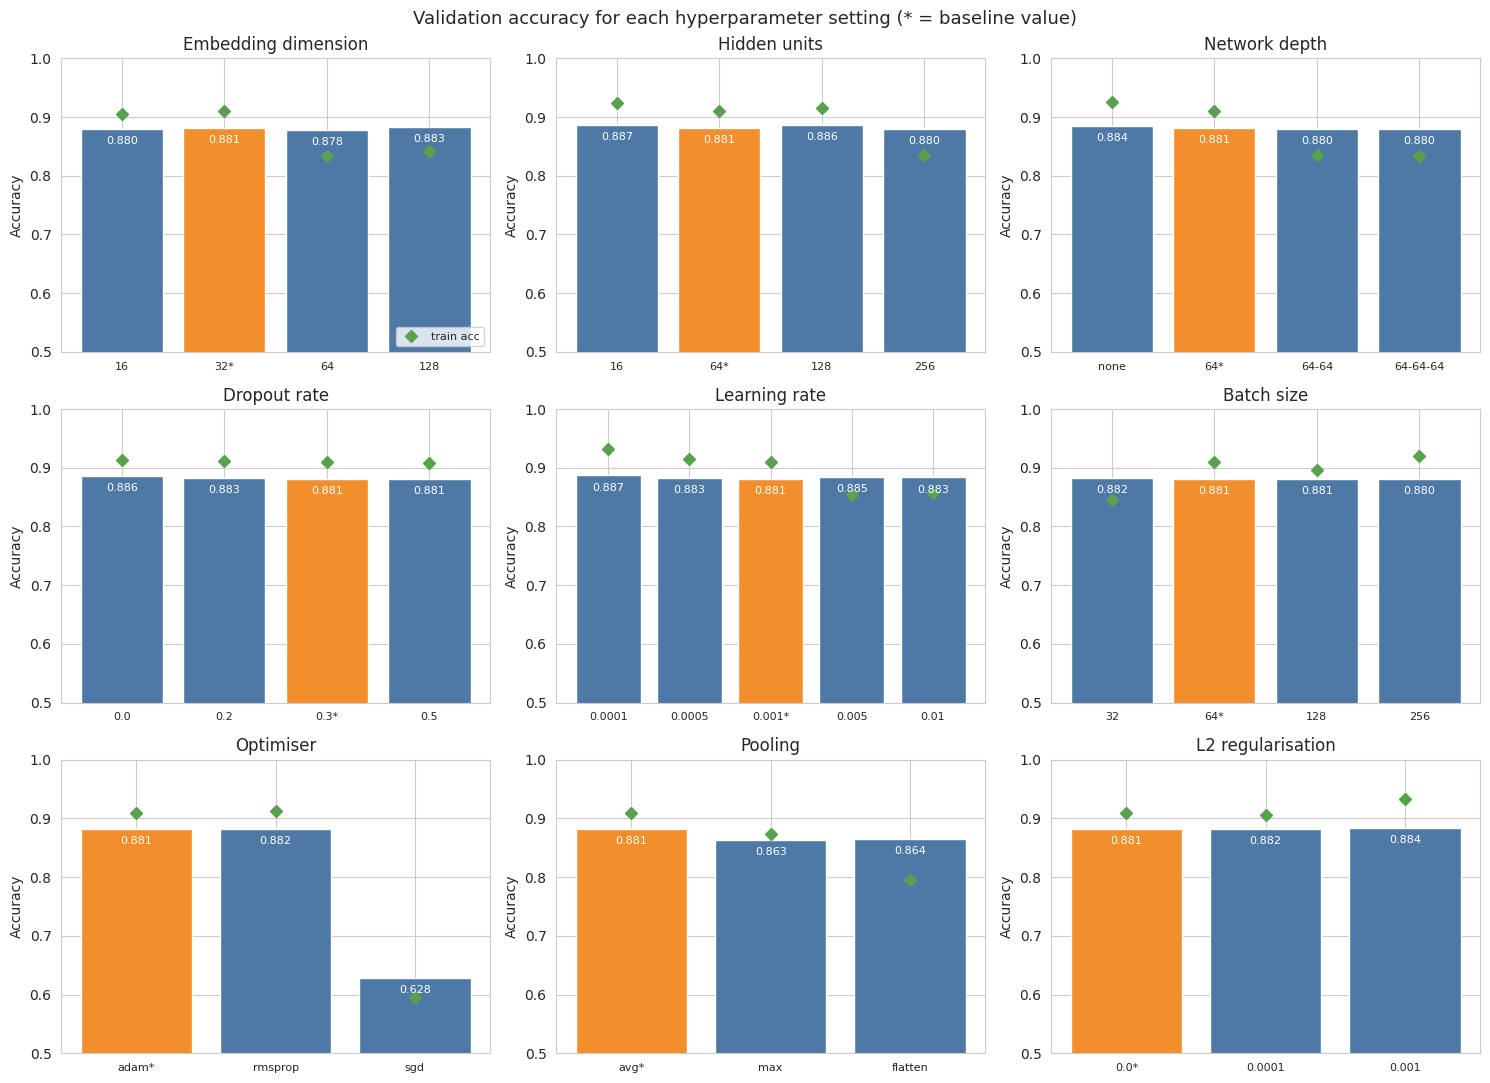

In [ ]:
ORDER = ["adam", "rmsprop", "sgd", "avg", "max", "flatten"]
def sort_key(v):
    if isinstance(v, list): return (len(v), sum(v))
    if isinstance(v, str):  return ORDER.index(v)
    return v

def group_frame(group):
    key = GRID[group][0]
    sub = results_df[(results_df["group"] == group) | (results_df["label"] == "baseline")].copy()
    sub["x"] = sub["cfg"].apply(lambda c: fmt(c[key]))
    sub["is_base"] = sub["label"] == "baseline"
    sub["order"] = sub["cfg"].apply(lambda c: sort_key(c[key]))
    return sub.sort_values("order")

fig, axes = plt.subplots(3, 3, figsize=(15, 11))
for ax, group in zip(axes.ravel(), GRID):
    sub = group_frame(group)
    colors = ["#f28e2b" if b else "#4e79a7" for b in sub["is_base"]]
    xs = [x + ("*" if b else "") for x, b in zip(sub["x"], sub["is_base"])]
    ax.bar(xs, sub["val_acc"], color=colors)
    ax.plot(xs, sub["train_acc"], "D", color="#59a14f", markersize=6, label="train acc")
    for i, v in enumerate(sub["val_acc"]):
        ax.text(i, v - 0.012, f"{v:.3f}", ha="center", va="top", fontsize=8, color="white")
    ax.set_ylim(0.5, 1.0); ax.set_title(group); ax.tick_params(axis="x", labelsize=8)
    ax.set_ylabel("Accuracy")
axes[0, 0].legend(loc="lower right", fontsize=8)
fig.suptitle("Validation accuracy for each hyperparameter setting (* = baseline value)", fontsize=13)
fig.tight_layout(); fig.savefig("figures/02_hyperparameter_summary.png"); plt.show()

### 6.3 Closer look: dropout and learning rate

Learning curves make overfitting (validation loss turning upward while training loss keeps falling) and slow/unstable optimisation easier to see than a single accuracy number.

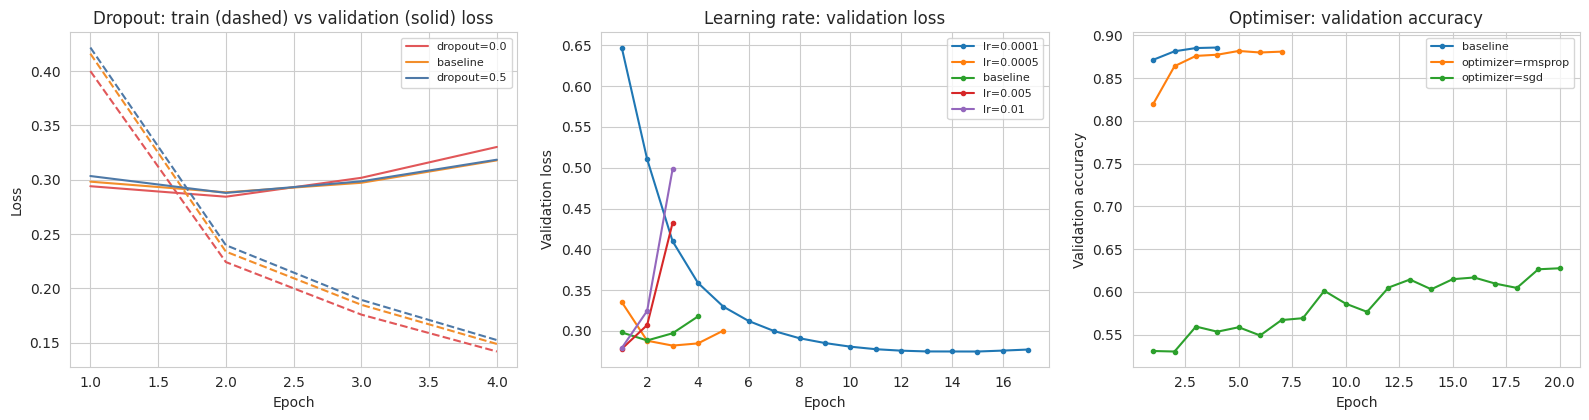

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.3))
for label, c in zip(["dropout=0.0", "baseline", "dropout=0.5"], ["#e15759", "#f28e2b", "#4e79a7"]):
    h = histories[label]; ep = range(1, len(h["loss"]) + 1)
    axes[0].plot(ep, h["loss"], "--", color=c); axes[0].plot(ep, h["val_loss"], "-", color=c, label=label)
axes[0].set(title="Dropout: train (dashed) vs validation (solid) loss", xlabel="Epoch", ylabel="Loss")
axes[0].legend(fontsize=8)

for label in ["lr=0.0001", "lr=0.0005", "baseline", "lr=0.005", "lr=0.01"]:
    h = histories[label]
    axes[1].plot(range(1, len(h["val_loss"]) + 1), h["val_loss"], "o-", markersize=3, label=label)
axes[1].set(title="Learning rate: validation loss", xlabel="Epoch", ylabel="Validation loss")
axes[1].legend(fontsize=8)

for label in ["baseline", "optimizer=rmsprop", "optimizer=sgd"]:
    h = histories[label]
    axes[2].plot(range(1, len(h["val_accuracy"]) + 1), h["val_accuracy"], "o-", markersize=3, label=label)
axes[2].set(title="Optimiser: validation accuracy", xlabel="Epoch", ylabel="Validation accuracy")
axes[2].legend(fontsize=8)
fig.tight_layout(); fig.savefig("figures/03_curves_dropout_lr_optimizer.png"); plt.show()

## 7. Choosing the final configuration

For every hyperparameter the best single-factor value (by validation accuracy, then validation loss) is selected
and the winners are **combined** into one configuration. Because hyperparameters interact, the combination is
itself trained and validated; the final configuration is whichever of {baseline, best single-factor runs,
combined run} scores best on the validation set.

In [ ]:
def better(df):
    return df.sort_values(["val_acc", "val_loss"], ascending=[False, True]).iloc[0]

base_only = results_df[results_df["label"] == "baseline"]
winners, combined = {}, dict(BASE)
for key in sorted({k for k, _ in GRID.values()}):
    pool = results_df[(results_df["group"] != "Baseline") &
                      results_df["cfg"].apply(lambda c: c[key] != BASE[key])]
    top = better(pd.concat([base_only, pool]))
    combined[key] = top["cfg"][key]
    winners[key] = (fmt(top["cfg"][key]), round(top["val_acc"], 4))
print("Best value per hyperparameter (value, val_acc):")
for k, v in winners.items():
    print(f"  {k:<10} -> {v[0]:<8} ({v[1]})")

row_c, hist_c = run_experiment("combined", combined, "Combined")
results.append(row_c); histories["combined"] = hist_c
results_df = pd.DataFrame(results)
print(f"\nCombined config validation accuracy: {row_c['val_acc']:.4f} (val_loss {row_c['val_loss']:.4f})")

best_row = better(results_df)
FINAL = best_row["cfg"]
print(f"Best overall run on validation: '{best_row['label']}'  val_acc={best_row['val_acc']:.4f}")
print("FINAL configuration:", {k: v for k, v in FINAL.items()})

Best value per hyperparameter (value, val_acc):
  batch      -> 32       (0.8822)
  dropout    -> 0.0      (0.8864)
  emb_dim    -> 128      (0.8832)
  hidden     -> 16       (0.8872)
  l2         -> 0.001    (0.8838)
  lr         -> 0.0001   (0.8868)
  optimizer  -> rmsprop  (0.8818)
  pool       -> avg      (0.8814)



Combined config validation accuracy: 0.8646 (val_loss 0.3544)
Best overall run on validation: 'hidden=16'  val_acc=0.8872
FINAL configuration: {'emb_dim': 32, 'hidden': [16], 'dropout': 0.3, 'lr': 0.001, 'optimizer': 'adam', 'batch': 64, 'pool': 'avg', 'l2': 0.0}


## 8. Final evaluation on the test set

The baseline and the final configuration are each trained with **three different random seeds** (42, 43, 44) and
evaluated once on the held-out test set. The seed-42 models are used for the confusion matrices and ROC curve;
the three-seed mean ± standard deviation shows whether the improvement is bigger than run-to-run noise.

In [ ]:
SEEDS = [42, 43, 44]
def train_and_test(cfg, seeds=SEEDS):
    rows, keep = [], {}
    for s in seeds:
        model, hist, secs = train_model(cfg, seed=s)
        p_val  = model.predict(X_valid, batch_size=512, verbose=0).ravel()
        p_test = model.predict(X_test,  batch_size=512, verbose=0).ravel()
        mv, mt = compute_metrics(y_valid, p_val), compute_metrics(y_test, p_test)
        rows.append(dict(seed=s, val_acc=mv["accuracy"], **{f"test_{k}": v for k, v in mt.items()}))
        if s == seeds[0]:
            keep = dict(model=model, hist=hist, p_test=p_test)
    return pd.DataFrame(rows), keep

base_runs,  base_keep  = train_and_test(BASE)
final_runs, final_keep = train_and_test(FINAL)

summary = pd.DataFrame({
    "Baseline (mean ± sd)": base_runs.drop(columns="seed").agg(lambda s: f"{s.mean():.4f} ± {s.std():.4f}"),
    "Final (mean ± sd)":    final_runs.drop(columns="seed").agg(lambda s: f"{s.mean():.4f} ± {s.std():.4f}"),
})
print("Per-seed test accuracy  baseline:", base_runs["test_accuracy"].round(4).tolist())
print("Per-seed test accuracy  final   :", final_runs["test_accuracy"].round(4).tolist(), "\n")
print(summary.to_string())

Per-seed test accuracy  baseline: [0.8854, 0.891, 0.8918]
Per-seed test accuracy  final   : [0.8874, 0.8906, 0.8912] 

               Baseline (mean ± sd) Final (mean ± sd)
val_acc             0.8858 ± 0.0038   0.8859 ± 0.0014
test_accuracy       0.8894 ± 0.0035   0.8897 ± 0.0020
test_precision      0.8756 ± 0.0163   0.8782 ± 0.0095
test_recall         0.9088 ± 0.0148   0.9057 ± 0.0093
test_f1             0.8917 ± 0.0015   0.8917 ± 0.0013
test_auc            0.9536 ± 0.0003   0.9533 ± 0.0004


### 8.1 Confusion matrix (final model, seed 42)

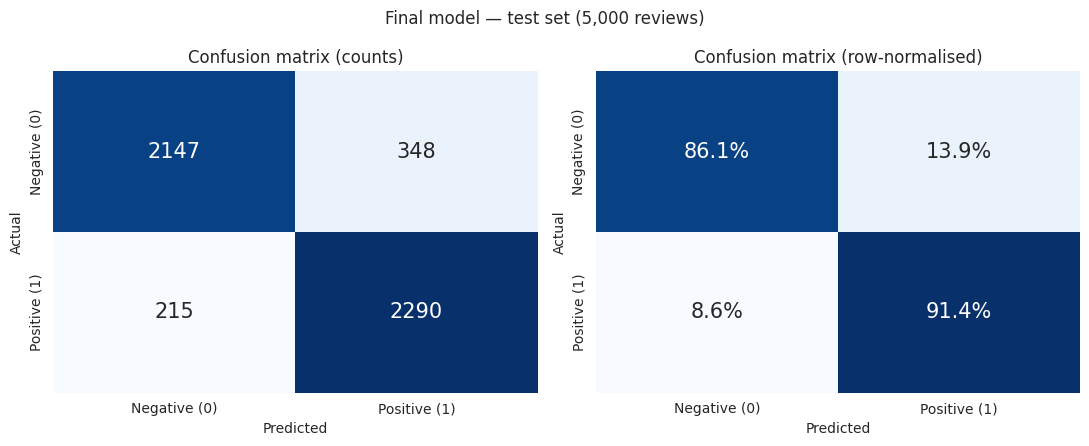

TN = 2147   FP = 348   FN = 215   TP = 2290


In [ ]:
p_test = final_keep["p_test"]
y_pred = (p_test >= 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
labels = ["Negative (0)", "Positive (1)"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels,
            ax=axes[0], cbar=False, annot_kws={"size": 15})
axes[0].set(title="Confusion matrix (counts)", xlabel="Predicted", ylabel="Actual")
sns.heatmap(cm / cm.sum(axis=1, keepdims=True), annot=True, fmt=".1%", cmap="Blues",
            xticklabels=labels, yticklabels=labels, ax=axes[1], cbar=False, annot_kws={"size": 15})
axes[1].set(title="Confusion matrix (row-normalised)", xlabel="Predicted", ylabel="Actual")
fig.suptitle("Final model — test set (5,000 reviews)"); fig.tight_layout()
fig.savefig("figures/04_confusion_matrix.png"); plt.show()

print(f"TN = {tn}   FP = {fp}   FN = {fn}   TP = {tp}")

### 8.2 Precision, recall and F-score

For the positive class: **precision** = TP / (TP + FP) (of reviews predicted positive, how many really are),
**recall** = TP / (TP + FN) (of truly positive reviews, how many were found) and
**F1** = 2·P·R / (P + R) (their harmonic mean).

In [ ]:
print(classification_report(y_test, y_pred, target_names=labels, digits=4))

prec = tp / (tp + fp); rec = tp / (tp + fn); f1 = 2 * prec * rec / (prec + rec)
print(f"Manual check (positive class): precision={prec:.4f}  recall={rec:.4f}  F1={f1:.4f}")
print(f"Test accuracy = {(tp + tn) / len(y_test):.4f}   ROC-AUC = {roc_auc_score(y_test, p_test):.4f}")

              precision    recall  f1-score   support

Negative (0)     0.9090    0.8605    0.8841      2495
Positive (1)     0.8681    0.9142    0.8905      2505

    accuracy                         0.8874      5000
   macro avg     0.8885    0.8873    0.8873      5000
weighted avg     0.8885    0.8874    0.8873      5000

Manual check (positive class): precision=0.8681  recall=0.9142  F1=0.8905
Test accuracy = 0.8874   ROC-AUC = 0.9536


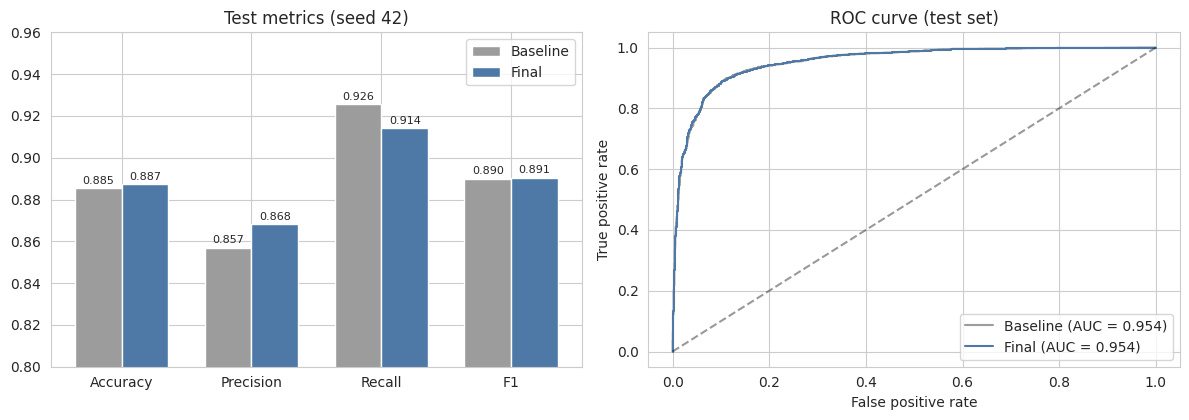

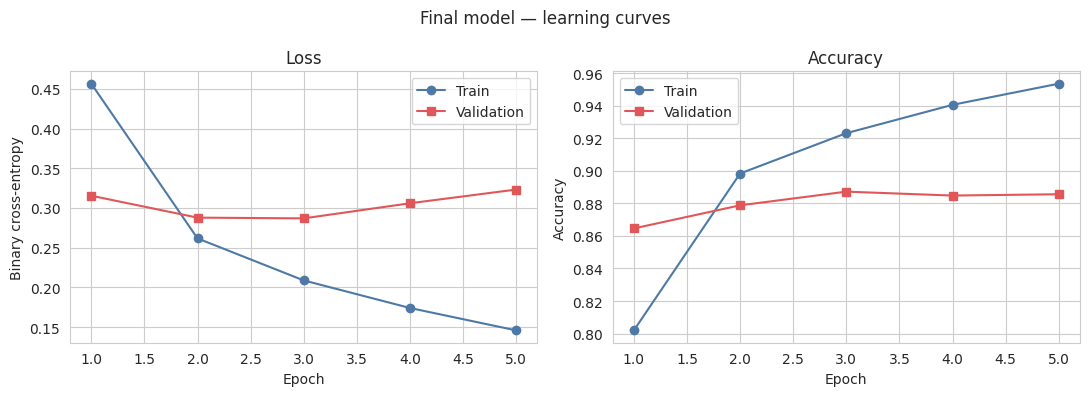

In [ ]:
# Baseline vs final (seed 42) on the test set: metrics + ROC curve
bm = compute_metrics(y_test, base_keep["p_test"]); fm = compute_metrics(y_test, final_keep["p_test"])
names = ["accuracy", "precision", "recall", "f1"]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
x = np.arange(len(names)); w = 0.36
axes[0].bar(x - w/2, [bm[n] for n in names], w, label="Baseline", color="#9c9c9c")
axes[0].bar(x + w/2, [fm[n] for n in names], w, label="Final", color="#4e79a7")
for i, n in enumerate(names):
    axes[0].text(i - w/2, bm[n] + 0.002, f"{bm[n]:.3f}", ha="center", fontsize=8)
    axes[0].text(i + w/2, fm[n] + 0.002, f"{fm[n]:.3f}", ha="center", fontsize=8)
axes[0].set_xticks(x); axes[0].set_xticklabels(["Accuracy", "Precision", "Recall", "F1"])
axes[0].set_ylim(0.80, 0.96); axes[0].set_title("Test metrics (seed 42)"); axes[0].legend()

for nm, p, c in [("Baseline", base_keep["p_test"], "#9c9c9c"), ("Final", final_keep["p_test"], "#4e79a7")]:
    fpr, tpr, _ = roc_curve(y_test, p)
    axes[1].plot(fpr, tpr, color=c, label=f"{nm} (AUC = {roc_auc_score(y_test, p):.3f})")
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[1].set(title="ROC curve (test set)", xlabel="False positive rate", ylabel="True positive rate")
axes[1].legend(loc="lower right")
fig.tight_layout(); fig.savefig("figures/05_baseline_vs_final.png"); plt.show()

plot_curves(final_keep["hist"], "Final model — learning curves", "figures/06_final_curves.png")

### 8.3 Error analysis

Where does the final model go wrong? Error rate by review length, and the most confident mistakes.

In [ ]:
test_eval = test.assign(prob=p_test, pred=y_pred)
test_eval["words"] = test_eval["clean_text"].str.split().str.len()
test_eval["error"] = (test_eval["pred"] != test_eval["label"]).astype(int)
test_eval["length_bin"] = pd.qcut(test_eval["words"], 4,
                                  labels=["Q1 shortest", "Q2", "Q3", "Q4 longest"])
print("Error rate by review length quartile:")
print(test_eval.groupby("length_bin", observed=True)["error"].agg(["mean", "sum"]).round(4)
      .rename(columns={"mean": "error_rate", "sum": "errors"}).to_string(), "\n")

def show(df, title, n=2):
    print(f"--- {title} ---")
    for _, r in df.head(n).iterrows():
        print(f"[P(positive)={r['prob']:.3f}]  {r['clean_text'][:230]}...\n")

fp_df = test_eval[(test_eval["label"] == 0) & (test_eval["pred"] == 1)].sort_values("prob", ascending=False)
fn_df = test_eval[(test_eval["label"] == 1) & (test_eval["pred"] == 0)].sort_values("prob")
show(fp_df, "Most confident FALSE POSITIVES (actually negative)")
show(fn_df, "Most confident FALSE NEGATIVES (actually positive)")

Error rate by review length quartile:
             error_rate  errors
length_bin                     
Q1 shortest      0.0960     121
Q2               0.0949     118
Q3               0.1167     146
Q4 longest       0.1429     178 

--- Most confident FALSE POSITIVES (actually negative) ---
[P(positive)=0.999]  this is definitely one of the best kung fu movies in the history of cinema the screenplay is really well done which is not often the case for this type of movies and you can see that chuck in one of his first role is a great actor...

[P(positive)=0.999]  nice movie and nicholle tom does a fantastic job playing the guy in the girl's body she really does it well a sort of teen version of many other movies but well done well casted from matt to matt...

--- Most confident FALSE NEGATIVES (actually positive) ---
[P(positive)=0.001]  this is simply the funniest movie i've seen in a long time the bad acting bad script bad scenery bad costumes bad camera work and bad special effects ar

In [ ]:
# Save the final model and a compact results summary
final_keep["model"].save("sentiment_ffnn_final.keras")
summary_out = dict(final_config={k: (v if not isinstance(v, list) else list(v)) for k, v in FINAL.items()},
                   test_metrics_seed42={k: round(float(v), 4) for k, v in fm.items()},
                   confusion_matrix=cm.tolist())
json.dump(summary_out, open("final_results.json", "w"), indent=2)
print(json.dumps(summary_out, indent=2))

{
  "final_config": {
    "emb_dim": 32,
    "hidden": [
      16
    ],
    "dropout": 0.3,
    "lr": 0.001,
    "optimizer": "adam",
    "batch": 64,
    "pool": "avg",
    "l2": 0.0
  },
  "test_metrics_seed42": {
    "accuracy": 0.8874,
    "precision": 0.8681,
    "recall": 0.9142,
    "f1": 0.8905,
    "auc": 0.9536
  },
  "confusion_matrix": [
    [
      2147,
      348
    ],
    [
      215,
      2290
    ]
  ]
}
